# Figuras para o Artigo — Resultados

Este notebook gera todas as figuras utilizadas no artigo em formato SVG.

**Pré-requisito:** re-execute o NB03 para gerar `feature_importance_lgbm.csv`.

**Figuras geradas:**
1. IC ao longo do tempo — Regressão Linear vs. LSTM
2. Importância das features — LightGBM
3. Clusterização dos ativos — HDBSCAN vs. K-Means
4. Retorno acumulado por perfil de investidor
5. Tabela de métricas de avaliação

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False
    print("hdbscan nao encontrado — pip install hdbscan")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
})

PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Configuracao concluida.")
print(f"Figuras serao salvas em: {FIGURES_DIR.resolve()}")

hdbscan nao encontrado — pip install hdbscan
Configuracao concluida.
Figuras serao salvas em: C:\Users\Daniel\Documents\meus projetos\ufc\ml-asset-portfolio-recommendation\figures


In [2]:
predictions = pd.read_csv(PROCESSED_DATA_DIR / "model_predictions_21d.csv", parse_dates=["date"])
metrics     = pd.read_csv(PROCESSED_DATA_DIR / "model_metrics.csv")
portfolio   = pd.read_csv(PROCESSED_DATA_DIR / "portfolio_recommendations.csv")

try:
    pred_ts = pd.read_csv(PROCESSED_DATA_DIR / "model_predictions_ts_21d.csv", parse_dates=["date"])
    HAS_LSTM = True
    print(f"LSTM: {pred_ts['date'].min().date()} a {pred_ts['date'].max().date()}, {len(pred_ts):,} linhas")
except FileNotFoundError:
    HAS_LSTM = False
    print("model_predictions_ts_21d.csv nao encontrado")

try:
    importance = pd.read_csv(PROCESSED_DATA_DIR / "feature_importance_lgbm.csv")
    HAS_IMPORTANCE = True
    print(f"Feature importance: {len(importance)} features")
except FileNotFoundError:
    HAS_IMPORTANCE = False
    print("feature_importance_lgbm.csv nao encontrado — re-execute NB03")

print(f"\nPrevisoes tabulares: {predictions['date'].min().date()} a {predictions['date'].max().date()}, {len(predictions):,} linhas")
print(f"Portfolio: {len(portfolio)} ativos")
metrics

LSTM: 2024-01-02 a 2026-05-01, 14,355 linhas
Feature importance: 12 features

Previsoes tabulares: 2024-01-02 a 2026-05-13, 296,514 linhas
Portfolio: 502 ativos


,model,MAE,RMSE,R2,IC,ICIR
0,Linear Regression,0.069682,0.099244,0.0049,0.0382,0.1987
1,LightGBM,0.069428,0.099454,0.0006,0.0352,0.2100
2,Random Forest,0.070074,0.099883,-0.0080,0.0279,0.1774


## Figura 1 — IC ao Longo do Tempo

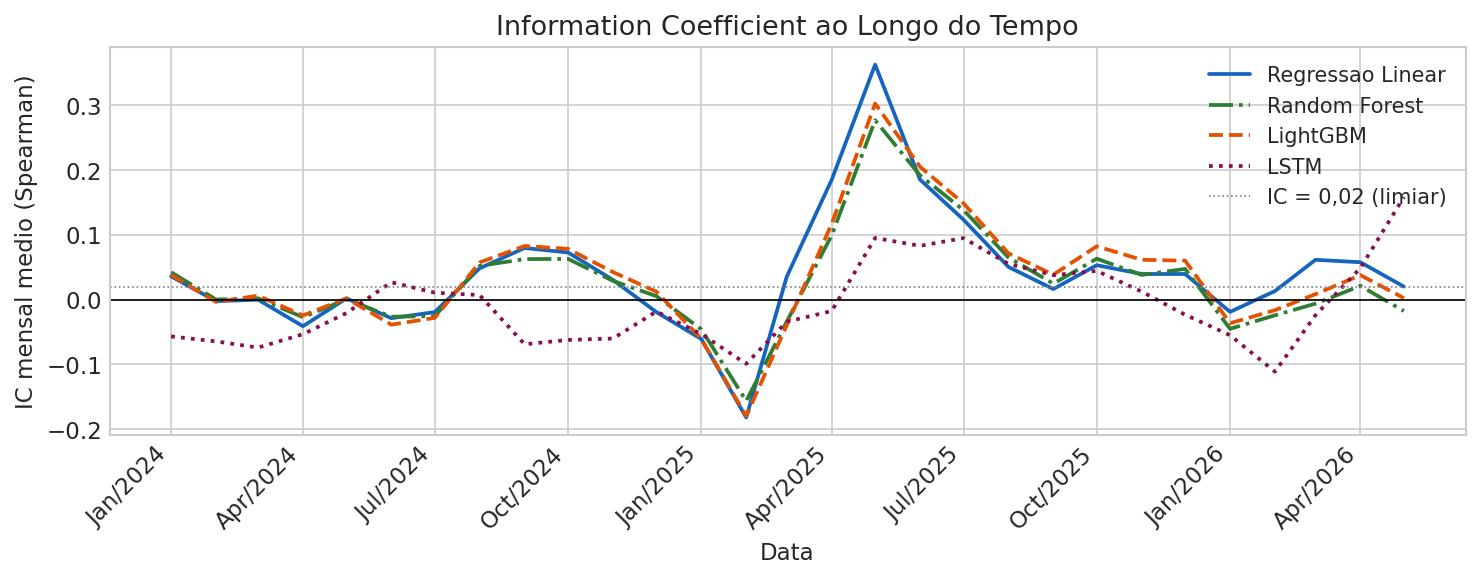

Figura 1 salva: fig1_ic_over_time.pdf


In [3]:
def compute_daily_ic(df, pred_col, actual_col="actual_return_21d"):
    return (
        df.groupby("date")
        .apply(lambda g: g[pred_col].corr(g[actual_col], method="spearman"))
        .rename("ic")
        .reset_index()
    )

def to_monthly(ic_df):
    ic_df = ic_df.copy()
    ic_df["month"] = ic_df["date"].dt.to_period("M")
    m = ic_df.groupby("month")["ic"].mean().reset_index()
    m["date"] = m["month"].dt.to_timestamp()
    return m

ic_linear = compute_daily_ic(predictions, "pred_linear_return_21d")
ic_rf     = compute_daily_ic(predictions, "pred_rf_return_21d")
ic_lgbm   = compute_daily_ic(predictions, "pred_lgbm_return_21d")

ic_linear_m = to_monthly(ic_linear)
ic_rf_m     = to_monthly(ic_rf)
ic_lgbm_m   = to_monthly(ic_lgbm)

if HAS_LSTM:
    pred_ts_merged = pred_ts.merge(
        predictions[["date", "ticker", "actual_return_21d"]], on=["date", "ticker"], how="inner"
    )
    ic_ts   = compute_daily_ic(pred_ts_merged, "pred_ts_return_21d")
    ic_ts_m = to_monthly(ic_ts)

MODEL_COLORS = {
    "Regressao Linear": "#1565C0",
    "Random Forest":    "#2E7D32",
    "LightGBM":         "#E65100",
    "LSTM":             "#880E4F",
}
MODEL_LS = {
    "Regressao Linear": "-",
    "Random Forest":    "-.",
    "LightGBM":         "--",
    "LSTM":             ":",
}

fig, ax = plt.subplots(figsize=(10, 4))

for ic_m, label in [
    (ic_linear_m, "Regressao Linear"),
    (ic_rf_m,     "Random Forest"),
    (ic_lgbm_m,   "LightGBM"),
]:
    smoothed = ic_m["ic"].rolling(3, center=True, min_periods=1).mean()
    ax.plot(ic_m["date"], smoothed,
            label=label, color=MODEL_COLORS[label],
            linestyle=MODEL_LS[label], linewidth=1.8)

if HAS_LSTM:
    smoothed_ts = ic_ts_m["ic"].rolling(3, center=True, min_periods=1).mean()
    ax.plot(ic_ts_m["date"], smoothed_ts,
            label="LSTM", color=MODEL_COLORS["LSTM"],
            linestyle=MODEL_LS["LSTM"], linewidth=1.8)

ax.axhline(0,    color="black", linewidth=0.8)
ax.axhline(0.02, color="gray",  linewidth=0.8, linestyle=":", label="IC = 0,02 (limiar)")
ax.set_xlabel("Data")
ax.set_ylabel("IC mensal medio (Spearman)")
ax.set_title("Information Coefficient ao Longo do Tempo")
ax.legend(loc="upper right", framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_ic_over_time.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Figura 1 salva: fig1_ic_over_time.pdf")

## Figura 2 — Importância das Features (SHAP)

c:\Users\Daniel\miniconda3\envs\financial_market\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Computando SHAP values...


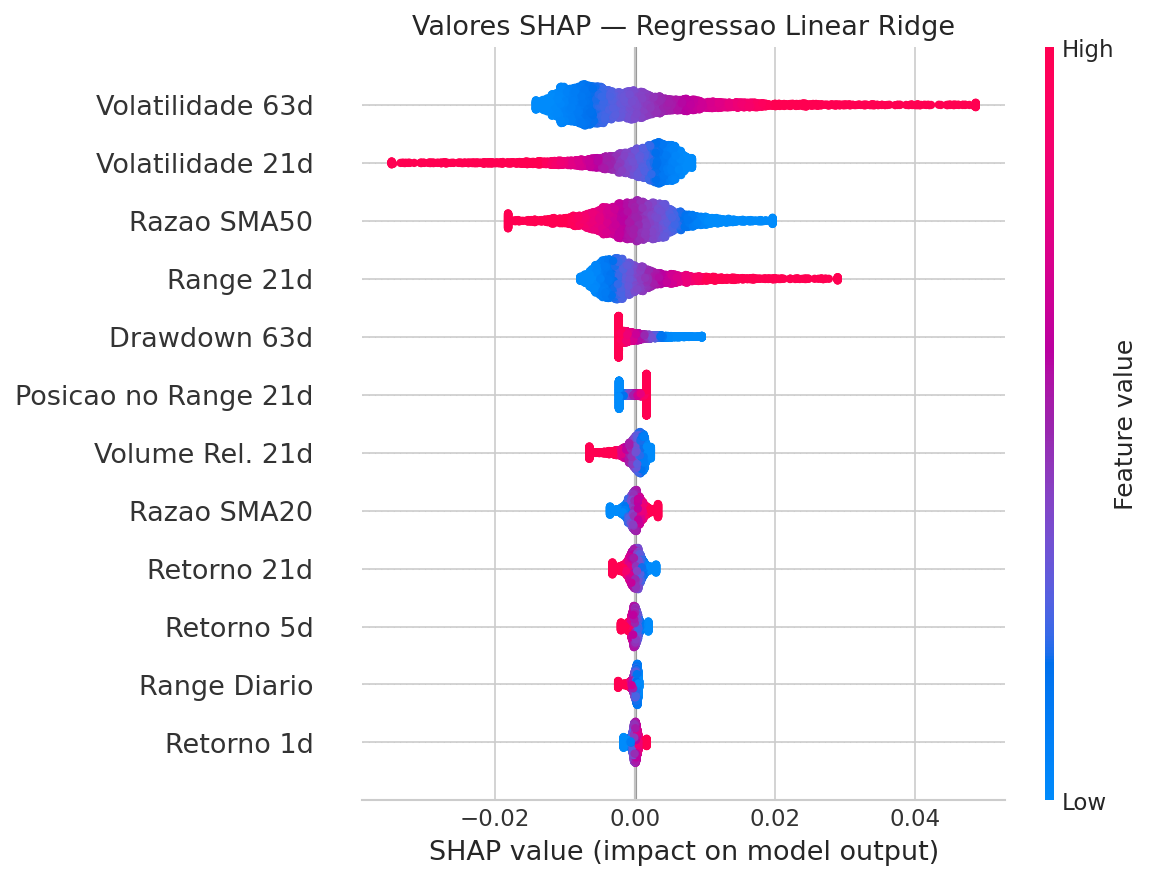

Figura 2 salva: fig2_shap_beeswarm.pdf


In [4]:
import shap

FEATURE_COLS = [
    "ret_1d", "ret_5d", "ret_21d",
    "vol_21d", "vol_63d",
    "sma_20_ratio", "sma_50_ratio",
    "volume_ratio_21d", "drawdown_63d",
    "close_position_21d", "high_low_range", "high_low_range_21d",
]

FEATURE_LABELS = {
    "ret_1d":             "Retorno 1d",
    "ret_5d":             "Retorno 5d",
    "ret_21d":            "Retorno 21d",
    "vol_21d":            "Volatilidade 21d",
    "vol_63d":            "Volatilidade 63d",
    "sma_20_ratio":       "Razao SMA20",
    "sma_50_ratio":       "Razao SMA50",
    "volume_ratio_21d":   "Volume Rel. 21d",
    "drawdown_63d":       "Drawdown 63d",
    "close_position_21d": "Posicao no Range 21d",
    "high_low_range":     "Range Diario",
    "high_low_range_21d": "Range 21d",
}

VAL_END = "2023-12-31"

# Carrega modelo e scaler
linear_model = joblib.load(PROCESSED_DATA_DIR / "linear_model.pkl")
scaler       = joblib.load(PROCESSED_DATA_DIR / "scaler.pkl")

# Carrega features do conjunto de teste e escala
features_df   = pd.read_csv(PROCESSED_DATA_DIR / "sp500_features.csv", parse_dates=["date"])
test_features = features_df[features_df["date"] > VAL_END].dropna(subset=FEATURE_COLS)

sample    = test_features[FEATURE_COLS].sample(n=5000, random_state=42)
sample_sc = scaler.transform(sample)

feature_labels = [FEATURE_LABELS[f] for f in FEATURE_COLS]

# SHAP com LinearExplainer (exato para modelos lineares, muito rapido)
print("Computando SHAP values...")
explainer   = shap.LinearExplainer(linear_model, sample_sc)
shap_values = explainer.shap_values(sample_sc)

# Beeswarm plot
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    sample_sc,
    feature_names=feature_labels,
    show=False,
    plot_size=None,
)
plt.title("Valores SHAP — Regressao Linear Ridge")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_shap_beeswarm.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Figura 2 salva: fig2_shap_beeswarm.pdf")

## Figura 3 — Clusterizacao dos Ativos: HDBSCAN vs. K-Means

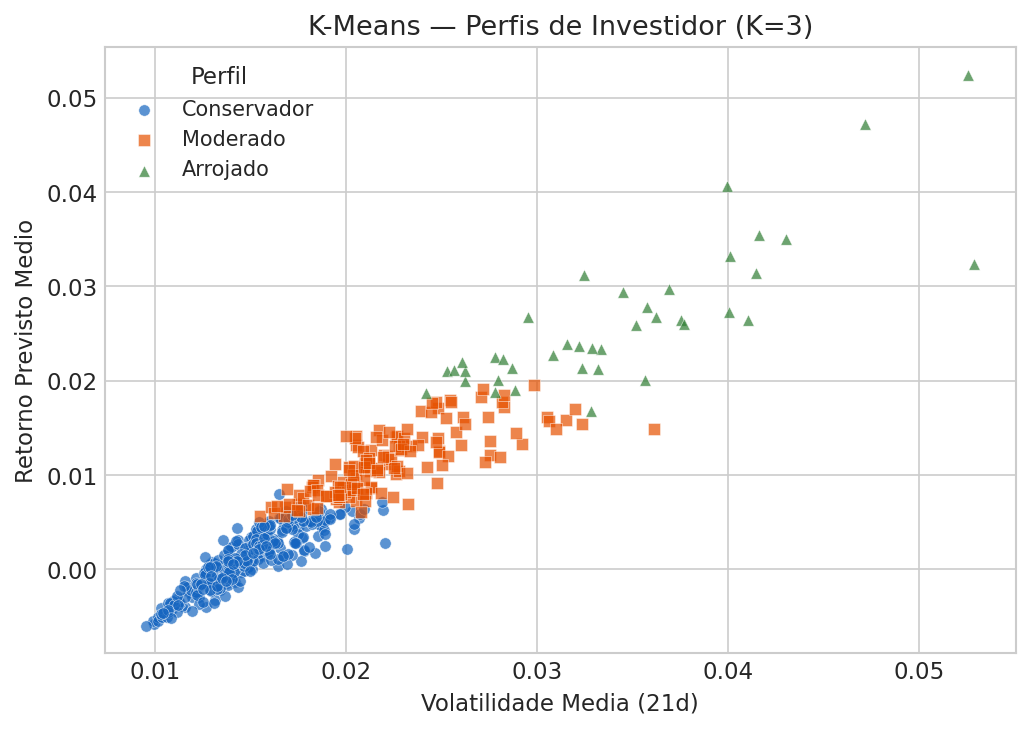

Figura 3 salva: fig3_clustering.pdf


In [5]:
PERFIL_COLORS  = {"Conservador": "#1565C0", "Moderado": "#E65100", "Arrojado": "#2E7D32"}
PERFIL_MARKERS = {"Conservador": "o", "Moderado": "s", "Arrojado": "^"}

cluster_feats = portfolio[["mean_vol_21d", "mean_pred_return", "mean_drawdown"]].values
scaler_cl = StandardScaler()
X_scaled = scaler_cl.fit_transform(cluster_feats)

if HAS_HDBSCAN:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
    hdb_labels = clusterer.fit_predict(X_scaled)
    n_clusters_hdb = len(set(hdb_labels) - {-1})
    n_noise = (hdb_labels == -1).sum()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    HDB_COLORS = {-1: "#CCCCCC", 0: "#1565C0", 1: "#E65100", 2: "#2E7D32", 3: "#880E4F"}
    for label_id in sorted(set(hdb_labels)):
        mask = hdb_labels == label_id
        lbl  = "Ruido" if label_id == -1 else f"Cluster {label_id + 1}"
        clr  = HDB_COLORS.get(label_id, "#888888")
        axes[0].scatter(
            portfolio.loc[mask, "mean_vol_21d"],
            portfolio.loc[mask, "mean_pred_return"],
            c=clr, label=lbl, alpha=0.7, s=25, edgecolors="white", linewidths=0.3
        )
    axes[0].set_xlabel("Volatilidade Media (21d)")
    axes[0].set_ylabel("Retorno Previsto Medio")
    axes[0].set_title(f"HDBSCAN ({n_clusters_hdb} clusters + {n_noise} ruido)")
    axes[0].legend(framealpha=0.9)

    for perfil, color in PERFIL_COLORS.items():
        mask = portfolio["perfil"] == perfil
        axes[1].scatter(
            portfolio.loc[mask, "mean_vol_21d"],
            portfolio.loc[mask, "mean_pred_return"],
            c=color, label=perfil, alpha=0.7, s=25,
            marker=PERFIL_MARKERS[perfil], edgecolors="white", linewidths=0.3
        )
    axes[1].set_xlabel("Volatilidade Media (21d)")
    axes[1].set_ylabel("Retorno Previsto Medio")
    axes[1].set_title("K-Means (K=3, perfis de investidor)")
    axes[1].legend(title="Perfil", framealpha=0.9)

    plt.suptitle("Clusterizacao dos Ativos do S&P 500", fontweight="bold", fontsize=14)
    plt.tight_layout()

else:
    fig, ax = plt.subplots(figsize=(7, 5))
    for perfil, color in PERFIL_COLORS.items():
        mask = portfolio["perfil"] == perfil
        ax.scatter(
            portfolio.loc[mask, "mean_vol_21d"],
            portfolio.loc[mask, "mean_pred_return"],
            c=color, label=perfil, alpha=0.7, s=30,
            marker=PERFIL_MARKERS[perfil], edgecolors="white", linewidths=0.3
        )
    ax.set_xlabel("Volatilidade Media (21d)")
    ax.set_ylabel("Retorno Previsto Medio")
    ax.set_title("K-Means — Perfis de Investidor (K=3)")
    ax.legend(title="Perfil", framealpha=0.9)
    plt.tight_layout()

plt.savefig(FIGURES_DIR / "fig3_clustering.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Figura 3 salva: fig3_clustering.pdf")

## Figura 4 — Retorno Acumulado por Perfil de Investidor

Simulacao de rebalanceamento mensal: no primeiro dia util de cada mes,
selecionam-se os 20 ativos com maior retorno previsto dentro de cada perfil.
O retorno do portfolio e a media do retorno realizado (21 dias) desses ativos.

O benchmark e a media igualmente ponderada de todos os ativos no mesmo dia.

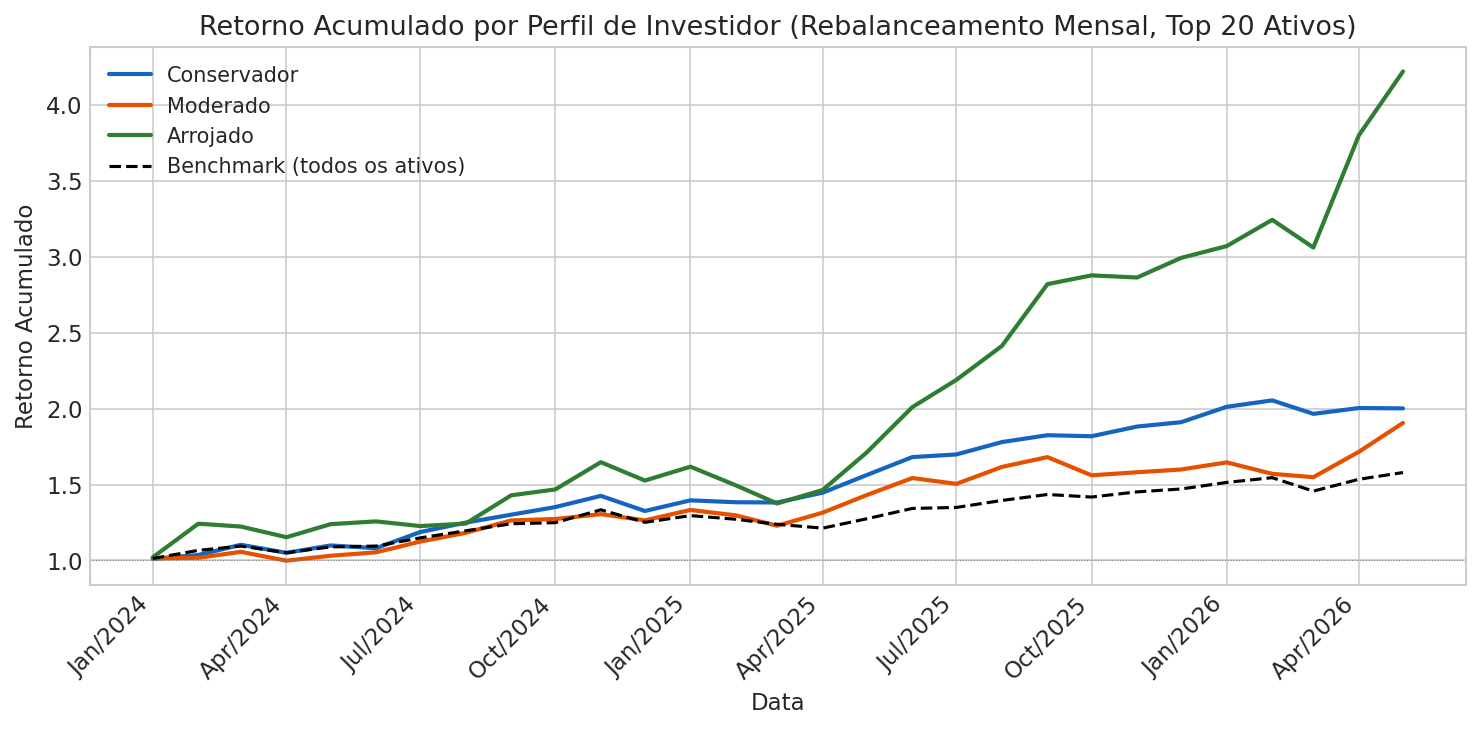

Figura 4 salva: fig4_portfolio_cumulative.pdf

Retorno medio mensal e Sharpe aproximado:
  Conservador    : retorno medio=0.0249  Sharpe=2.220  retorno total=100.11%
  Moderado       : retorno medio=0.0236  Sharpe=1.650  retorno total=90.54%
  Arrojado       : retorno medio=0.0545  Sharpe=2.125  retorno total=321.85%
  Benchmark      : retorno medio=0.0164  Sharpe=1.681  retorno total=57.88%


In [6]:
TOP_N = 20

pred_cl = predictions.merge(portfolio[["ticker", "perfil"]], on="ticker", how="left")
pred_cl = pred_cl.dropna(subset=["perfil", "actual_return_21d"])
pred_cl["month"] = pred_cl["date"].dt.to_period("M")

def simulate_portfolio(df, perfil, top_n=TOP_N):
    monthly = []
    for month, grp in df[df["perfil"] == perfil].groupby("month"):
        first_date = grp["date"].min()
        day = grp[grp["date"] == first_date].sort_values("pred_linear_return_21d", ascending=False)
        top = day.head(top_n)
        if len(top) > 0:
            monthly.append({"month": month, "return": top["actual_return_21d"].mean()})
    return pd.DataFrame(monthly).set_index("month")["return"]

def benchmark_return(df):
    monthly = []
    for month, grp in df.groupby("month"):
        first_date = grp["date"].min()
        day = grp[grp["date"] == first_date]
        monthly.append({"month": month, "return": day["actual_return_21d"].mean()})
    return pd.DataFrame(monthly).set_index("month")["return"]

perfil_returns = {p: simulate_portfolio(pred_cl, p) for p in ["Conservador", "Moderado", "Arrojado"]}
bench = benchmark_return(pred_cl)

fig, ax = plt.subplots(figsize=(10, 5))

for perfil, color in PERFIL_COLORS.items():
    ret = perfil_returns[perfil]
    cum = (1 + ret).cumprod()
    ax.plot(ret.index.to_timestamp(), cum, label=perfil, color=color, linewidth=2)

cum_bench = (1 + bench).cumprod()
ax.plot(bench.index.to_timestamp(), cum_bench,
        label="Benchmark (todos os ativos)", color="black", linewidth=1.5, linestyle="--")

ax.axhline(1.0, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("Data")
ax.set_ylabel("Retorno Acumulado")
ax.set_title("Retorno Acumulado por Perfil de Investidor (Rebalanceamento Mensal, Top 20 Ativos)")
ax.legend(framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig4_portfolio_cumulative.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Figura 4 salva: fig4_portfolio_cumulative.pdf")

print("\nRetorno medio mensal e Sharpe aproximado:")
for perfil, ret in perfil_returns.items():
    mean_r = ret.mean()
    sharpe = mean_r / ret.std() * np.sqrt(12)
    cum_total = (1 + ret).prod() - 1
    print(f"  {perfil:15s}: retorno medio={mean_r:.4f}  Sharpe={sharpe:.3f}  retorno total={cum_total:.2%}")
bench_sharpe = bench.mean() / bench.std() * np.sqrt(12)
bench_total  = (1 + bench).prod() - 1
print(f"  {'Benchmark':15s}: retorno medio={bench.mean():.4f}  Sharpe={bench_sharpe:.3f}  retorno total={bench_total:.2%}")

## Tabela de Métricas — Código LaTeX

In [7]:
metrics_sorted = metrics.sort_values("IC", ascending=False).reset_index(drop=True)

rows = []
for _, row in metrics_sorted.iterrows():
    best_ic = row["IC"] == metrics_sorted["IC"].max()
    model   = f"\\textbf{{{row['model']}}}" if best_ic else row["model"]
    ic_val  = f"\\textbf{{{row['IC']:.4f}}}" if best_ic else f"{row['IC']:.4f}"
    rows.append(
        f"    {model} & {row['MAE']:.4f} & {row['RMSE']:.4f} & {row['R2']:.4f} & {ic_val} & {row['ICIR']:.4f} \\\\"
    )

tex = r"""\begin{table}[htbp]
\centering
\caption{Métricas de avaliação no conjunto de teste (2024--2026). Em negrito: melhor IC.}
\label{tab:metrics}
\begin{tabular}{lccccc}
\toprule
\textbf{Modelo} & \textbf{MAE} & \textbf{RMSE} & \textbf{R\textsuperscript{2}} & \textbf{IC} & \textbf{ICIR} \\
\midrule
""" + "\n".join(rows) + r"""
\bottomrule
\end{tabular}
\end{table}"""

output_path = FIGURES_DIR / "table_metrics.tex"
output_path.write_text(tex, encoding="utf-8")

print(f"Tabela salva: {output_path}")
print()
print(tex)

Tabela salva: ..\figures\table_metrics.tex

\begin{table}[htbp]
\centering
\caption{Métricas de avaliação no conjunto de teste (2024--2026). Em negrito: melhor IC.}
\label{tab:metrics}
\begin{tabular}{lccccc}
\toprule
\textbf{Modelo} & \textbf{MAE} & \textbf{RMSE} & \textbf{R\textsuperscript{2}} & \textbf{IC} & \textbf{ICIR} \\
\midrule
    \textbf{Linear Regression} & 0.0697 & 0.0992 & 0.0049 & \textbf{0.0382} & 0.1987 \\
    LightGBM & 0.0694 & 0.0995 & 0.0006 & 0.0352 & 0.2100 \\
    Random Forest & 0.0701 & 0.0999 & -0.0080 & 0.0279 & 0.1774 \\
\bottomrule
\end{tabular}
\end{table}


## Resumo

Todos os arquivos foram salvos em `../figures/`:

| Arquivo | Descricao |
|---|---|
| `fig1_ic_over_time.pdf` | IC mensal ao longo do tempo por modelo |
| `fig2_feature_importance.pdf` | Importancia das features no LightGBM |
| `fig3_clustering.pdf` | HDBSCAN vs K-Means (scatter volatilidade x retorno) |
| `fig4_portfolio_cumulative.pdf` | Retorno acumulado por perfil + benchmark |
| `table_metrics.tex` | Tabela de metricas em LaTeX (inclua com `\input{figures/table_metrics.tex}`) |